In [2]:
import pandas as pd
import os
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Automatically find the path to handle hidden spaces
base_path = '/content/drive/MyDrive/'
folders = [f for f in os.listdir(base_path) if 'Assignment 4' in f]

if folders:
    # Use the first folder that matches
    actual_folder_name = folders[0]
    file_path = os.path.join(base_path, actual_folder_name, 'q1_heart_disease.csv')

    # 3. Load the file
    df = pd.read_csv(file_path)
    print(f"✅ Success! Loaded from: {file_path}")
    display(df.head())
else:
    print("❌ Could not find a folder named 'Assignment 4'.")
    print("Folders actually found in your Drive:", os.listdir(base_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Success! Loaded from: /content/drive/MyDrive/Assignment 4 /q1_heart_disease.csv


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [3]:
# Display shape, data types, and missing values
print(f"Dataset Shape: {df.shape}")
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Value Counts ---")
print(df.isnull().sum())

# Show the first five rows
print("\n--- First Five Rows ---")
df.head()

Dataset Shape: (800, 12)

--- Data Types ---
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

--- Missing Value Counts ---
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

--- First Five Rows ---


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


/tmp/ipykernel_8075/1198107790.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heart_disease', data=df, palette='Set2')


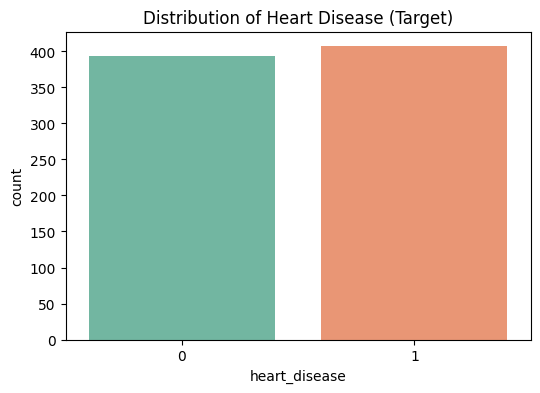

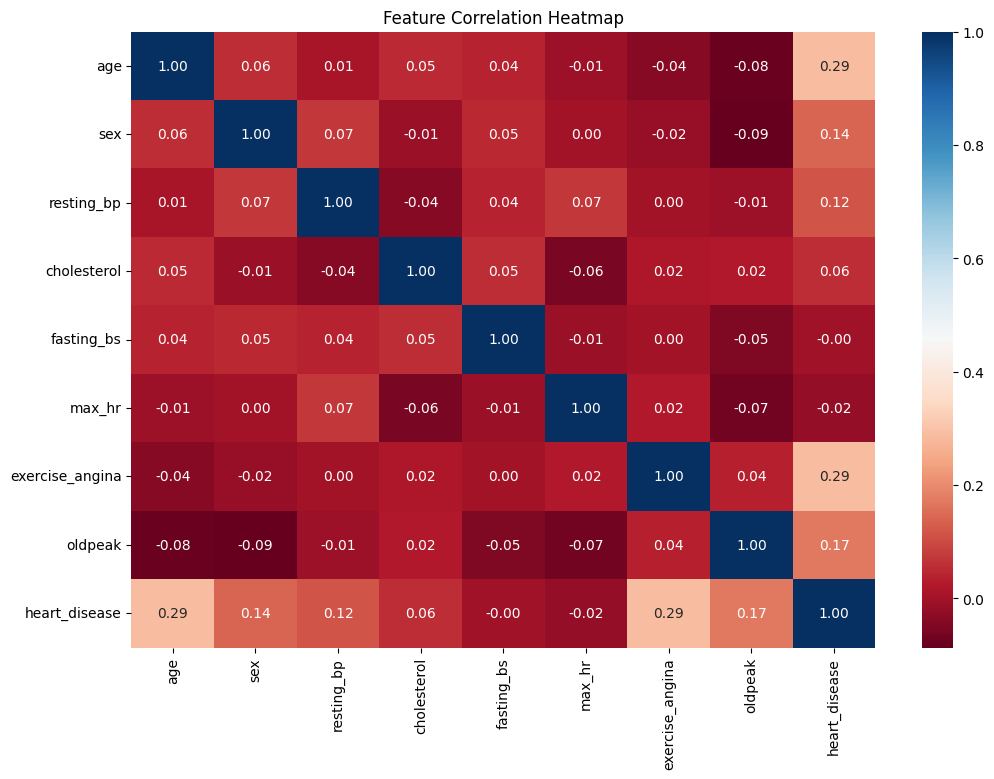

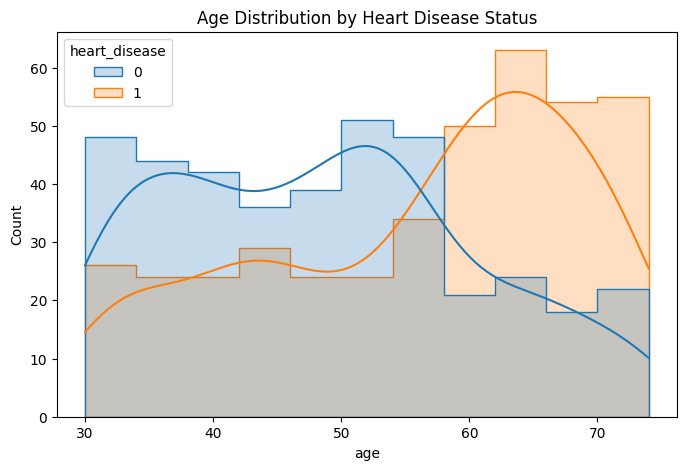

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Target Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='heart_disease', data=df, palette='Set2')
plt.title('Distribution of Heart Disease (Target)')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
# We use .select_dtypes to ensure we only correlate numbers, not text
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# 3. Age vs Heart Disease
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='heart_disease', kde=True, element="step")
plt.title('Age Distribution by Heart Disease Status')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Handle Missing Values
# We fill numerical missing values with the median
df = df.fillna(df.median(numeric_only=True))

# 2. One-Hot Encoding
# This converts columns like 'sex' or 'chest_pain_type' into multiple columns of 0s and 1s
df_encoded = pd.get_dummies(df, drop_first=True)

# 3. Split the data into Features (X) and Target (y)
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# 4. Train-Test Split
# We use 80% for training and 20% for testing.
# stratify=y ensures both sets have the same percentage of heart disease cases.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 5. Scaling
# Some features like 'cholesterol' are in the 100s, while 'oldpeak' is small.
# Scaling makes them all comparable.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete. Training data shape:", X_train_scaled.shape)

Preprocessing complete. Training data shape: (640, 15)


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Define the models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Loop through each model, train it, and print results
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Print results
    print(f"\n================ {name} ================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


================ Decision Tree ================
Confusion Matrix:
[[57 22]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


================ Random Forest ================
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


================ Gradient Boosting ================
Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
            

In [7]:
from sklearn.model_selection import GridSearchCV

# Define the settings (hyperparameters) we want to test
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Run the search (this might take 30 seconds)
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_scaled, y_train)

# Best settings found
print("Best Parameters:", grid_search.best_params_)

# Evaluate the tuned model
tuned_model = grid_search.best_estimator_
tuned_pred = tuned_model.predict(X_test_scaled)

print("\n--- Tuned Random Forest Performance ---")
print(classification_report(y_test, tuned_pred))

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

--- Tuned Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.79      0.72      0.75        79
           1       0.75      0.81      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160

